# Week 9 — Machine Learning for Forecasting

This notebook introduces ML methods for forecasting: regularised regression (Ridge, Lasso), decision trees, and random forests — with the bias-variance tradeoff as the guiding framework.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Edinburgh palette
UOE_RED   = '#7A2318'
UOE_GOLD  = '#B8860B'
UOE_BLUE  = '#2a78d6'
UOE_GREY  = '#52514e'
COLOURS   = [UOE_RED, UOE_BLUE, UOE_GOLD, '#2ca02c', '#9467bd', '#e377c2']

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.prop_cycle': mpl.cycler(color=COLOURS),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'font.size': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2,
})
print("Plotting style set ✓")


Plotting style set ✓


## 9.1 The Bias-Variance Tradeoff

$$\text{MSE} = \text{Bias}^2 + \text{Variance} + \text{Irreducible noise}$$

Traditional econometrics focuses on unbiasedness. ML accepts a little bias to reduce variance — especially helpful when $p$ is large relative to $T$.

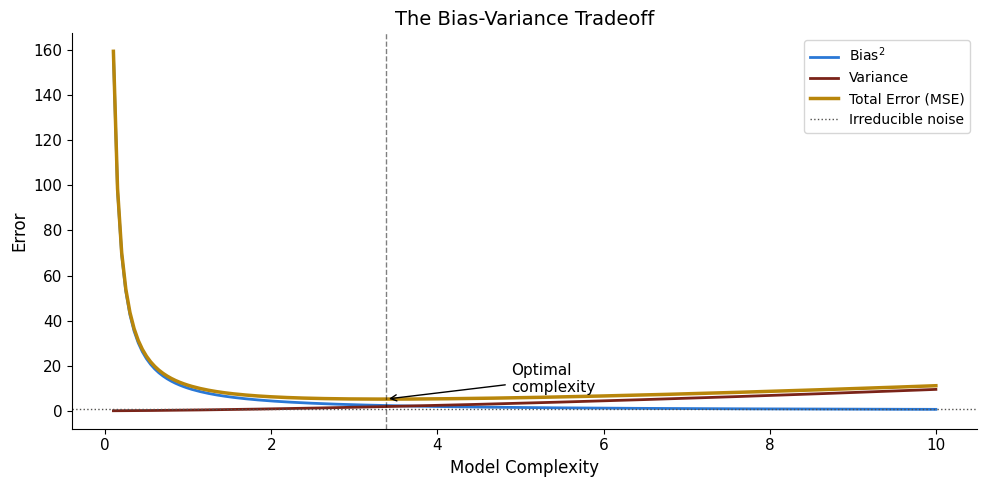

In [2]:
# Visualise the bias-variance tradeoff
complexity = np.linspace(0.1, 10, 200)
bias_sq = 10 / complexity**1.2
variance = 0.3 * complexity**1.5
total = bias_sq + variance + 1  # +1 irreducible

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(complexity, bias_sq, color=UOE_BLUE, lw=2, label='Bias$^2$')
ax.plot(complexity, variance, color=UOE_RED, lw=2, label='Variance')
ax.plot(complexity, total, color=UOE_GOLD, lw=2.5, label='Total Error (MSE)')
ax.axhline(1, ls=':', color=UOE_GREY, lw=1, label='Irreducible noise')
opt = complexity[np.argmin(total)]
ax.axvline(opt, ls='--', color='k', lw=1, alpha=0.5)
ax.annotate('Optimal\ncomplexity', xy=(opt, np.min(total)),
            xytext=(opt+1.5, np.min(total)+3),
            arrowprops=dict(arrowstyle='->', color='k'), fontsize=11)
ax.set_xlabel('Model Complexity')
ax.set_ylabel('Error')
ax.set_title('The Bias-Variance Tradeoff')
ax.legend()
plt.tight_layout()
plt.show()


## 9.2 Ridge and Lasso Regression

$$\hat{\beta}_{\text{Ridge}} = \arg\min \|y - X\beta\|^2 + \lambda \|\beta\|_2^2$$
$$\hat{\beta}_{\text{Lasso}} = \arg\min \|y - X\beta\|^2 + \lambda \|\beta\|_1$$

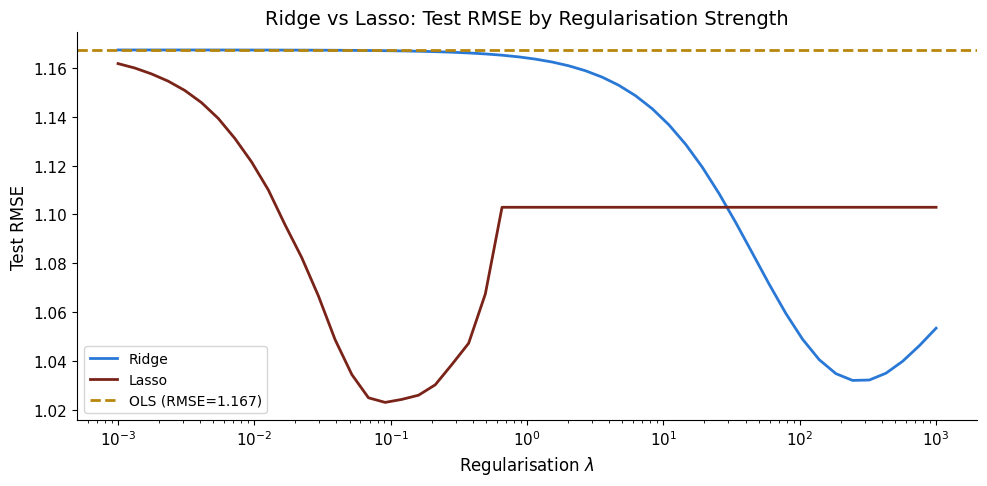

In [3]:
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_squared_error

# Simulate high-dimensional forecasting: many lags, some irrelevant
np.random.seed(42)
T = 300
y_ar = np.zeros(T)
for t in range(3, T):
    y_ar[t] = 0.5*y_ar[t-1] + 0.2*y_ar[t-2] - 0.1*y_ar[t-3] + np.random.normal(0, 1)

# Create feature matrix with many lags (some useful, most noise)
n_lags = 30
X = np.column_stack([y_ar[n_lags-1-j:T-1-j] for j in range(n_lags)])
y_target = y_ar[n_lags:]
X_train, X_test = X[:200], X[200:]
y_train, y_test = y_target[:200], y_target[200:]

# Compare methods
alphas = np.logspace(-3, 3, 50)
ols_rmse = np.sqrt(mean_squared_error(y_test,
                   LinearRegression().fit(X_train, y_train).predict(X_test)))
ridge_rmses = []
lasso_rmses = []

for a in alphas:
    ridge_rmses.append(np.sqrt(mean_squared_error(y_test,
                       Ridge(alpha=a).fit(X_train, y_train).predict(X_test))))
    lasso_rmses.append(np.sqrt(mean_squared_error(y_test,
                       Lasso(alpha=a, max_iter=10000).fit(X_train, y_train).predict(X_test))))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(alphas, ridge_rmses, color=UOE_BLUE, lw=2, label='Ridge')
ax.semilogx(alphas, lasso_rmses, color=UOE_RED, lw=2, label='Lasso')
ax.axhline(ols_rmse, ls='--', color=UOE_GOLD, lw=2, label=f'OLS (RMSE={ols_rmse:.3f})')
ax.set_xlabel('Regularisation $\\lambda$')
ax.set_ylabel('Test RMSE')
ax.set_title('Ridge vs Lasso: Test RMSE by Regularisation Strength')
ax.legend()
plt.tight_layout()
plt.show()


## 9.3 Lasso Coefficient Paths

Lasso sets irrelevant coefficients exactly to zero — automatic variable selection.

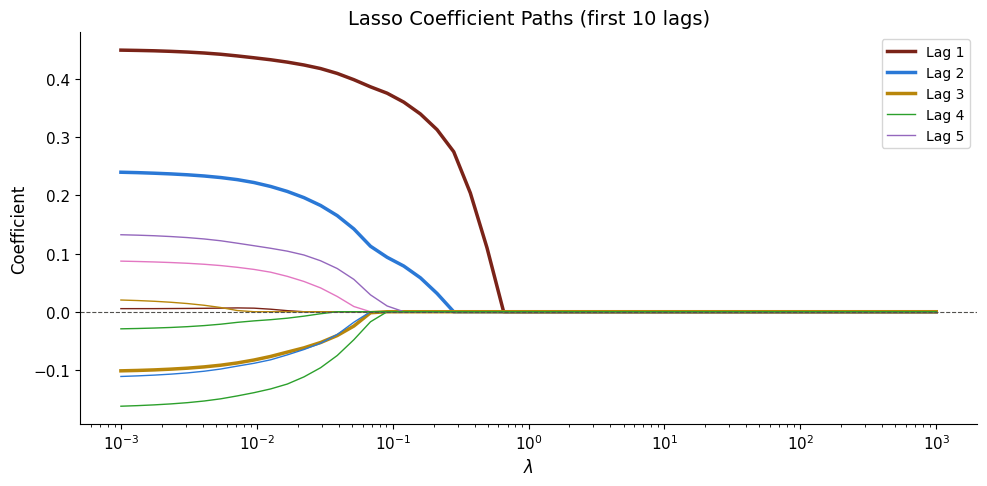

In [4]:
# Lasso path
coefs = []
for a in alphas:
    lasso = Lasso(alpha=a, max_iter=10000).fit(X_train, y_train)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)

fig, ax = plt.subplots(figsize=(10, 5))
for j in range(min(n_lags, 10)):
    col = COLOURS[j % len(COLOURS)]
    lw = 2.5 if j < 3 else 1
    ax.semilogx(alphas, coefs[:, j], color=col, lw=lw,
                label=f'Lag {j+1}' if j < 5 else None)
ax.axhline(0, ls='--', color=UOE_GREY, lw=0.8)
ax.set_xlabel('$\\lambda$')
ax.set_ylabel('Coefficient')
ax.set_title('Lasso Coefficient Paths (first 10 lags)')
ax.legend()
plt.tight_layout()
plt.show()


## 9.4 Random Forests for Time Series

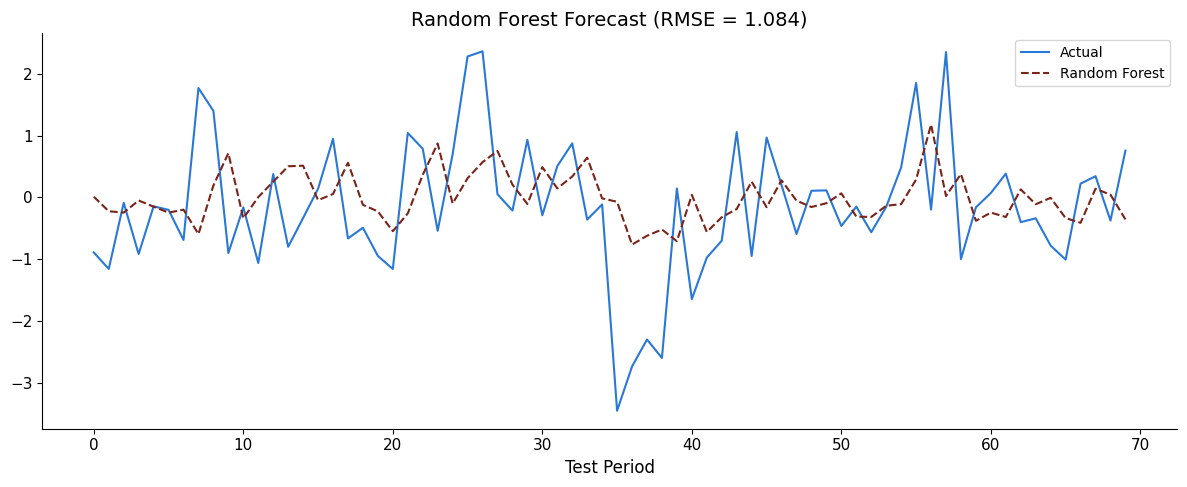

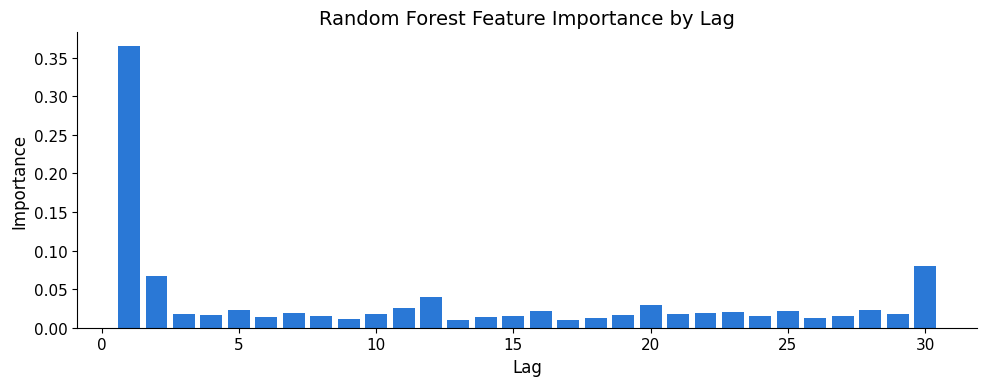

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_test, color=UOE_BLUE, lw=1.5, label='Actual')
ax.plot(rf_pred, '--', color=UOE_RED, lw=1.5, label='Random Forest')
ax.set_title(f'Random Forest Forecast (RMSE = {np.sqrt(mean_squared_error(y_test, rf_pred)):.3f})')
ax.set_xlabel('Test Period')
ax.legend()
plt.tight_layout()
plt.show()

# Feature importance
importances = rf.feature_importances_
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, n_lags+1), importances, color=UOE_BLUE)
ax.set_xlabel('Lag')
ax.set_ylabel('Importance')
ax.set_title('Random Forest Feature Importance by Lag')
plt.tight_layout()
plt.show()


## Exercises

<details><summary>Exercise 1: Use cross-validation to find the optimal Ridge penalty.</summary>

```python
from sklearn.linear_model import RidgeCV
rcv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
rcv.fit(X_train, y_train)
print(f'Best alpha: {rcv.alpha_:.4f}')
print(f'Test RMSE: {np.sqrt(mean_squared_error(y_test, rcv.predict(X_test))):.4f}')
```
</details>